# Crop geometry

Extracts a cubic sub-volume from the 256³ sphere-pack `.mat` file, inspects it, visualises it with PyVista, and saves it as a new `.mat` file named `374_05_03_<SIZE>.mat` under this folder.

**Convention:** `bin = 1` → solid grain, `bin = 0` → pore space (unchanged from source).

In [1]:
from pathlib import Path
import os
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

os.environ['PYVISTA_OFF_SCREEN'] = 'true'
pv.set_jupyter_backend('trame')
pv.global_theme.trame.server_proxy_enabled = True
pv.global_theme.trame.server_proxy_prefix = "/proxy/"

# ── Parameters ────────────────────────────────────────────────────────────────
CUBE_SIZE   = 96                                         # side length of the cropped cube
SOURCE_MAT  = Path('../../assets/374_05_03_256.mat')      # source geometry
OUTPUT_DIR  = Path('.')                                   # save cropped .mat here
# ──────────────────────────────────────────────────────────────────────────────

OUTPUT_MAT  = OUTPUT_DIR / f'374_05_03_{CUBE_SIZE}.mat'
print(f'Source : {SOURCE_MAT}')
print(f'Output : {OUTPUT_MAT}')
print(f'Size   : {CUBE_SIZE}³')

Source : ../../assets/374_05_03_256.mat
Output : 374_05_03_96.mat
Size   : 96³


In [2]:
# ── Load source geometry ───────────────────────────────────────────────────────
with h5py.File(SOURCE_MAT, 'r') as f:
    full = np.array(f['bin'], dtype=np.uint8)   # (256, 256, 256)  1=solid

GX, GY, GZ = full.shape
print(f'Full geometry  : {GX} x {GY} x {GZ}')
print(f'Solid fraction : {full.mean():.4f}')

Full geometry  : 256 x 256 x 256
Solid fraction : 0.6190


In [3]:
# ── Crop from centre ───────────────────────────────────────────────────────────
assert CUBE_SIZE <= min(GX, GY, GZ), f'CUBE_SIZE {CUBE_SIZE} exceeds geometry dims {full.shape}'

# sx = (GX - CUBE_SIZE) // 2
# sy = (GY - CUBE_SIZE) // 2
# sz = (GZ - CUBE_SIZE) // 2

sx = 64
sy = 64
sz = 64

cropped = full[sx:sx+CUBE_SIZE, sy:sy+CUBE_SIZE, sz:sz+CUBE_SIZE]

print(f'Crop origin    : ({sx}, {sy}, {sz})')
print(f'Cropped shape  : {cropped.shape}')
print(f'Solid fraction : {cropped.mean():.4f}')
print(f'Pore fraction  : {1 - cropped.mean():.4f}')

Crop origin    : (64, 64, 64)
Cropped shape  : (96, 96, 96)
Solid fraction : 0.6227
Pore fraction  : 0.3773


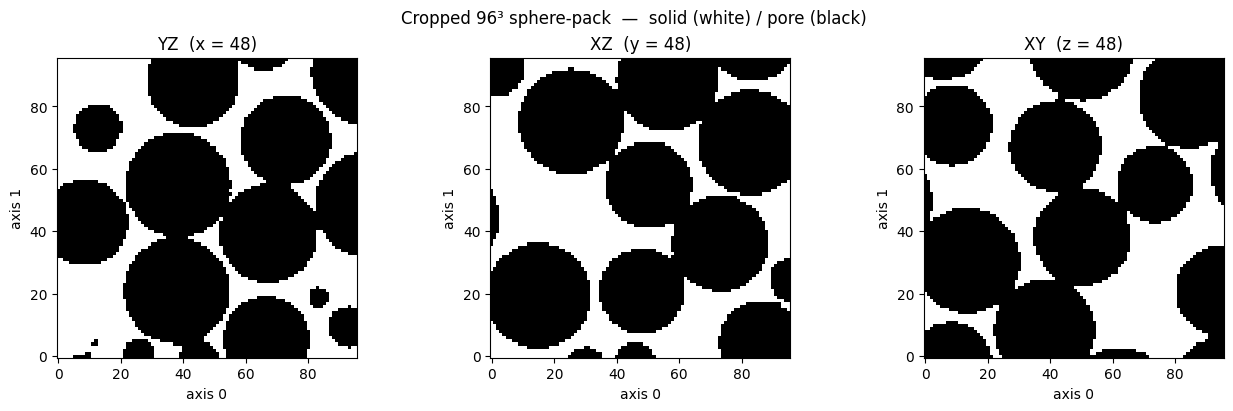

In [4]:
# ── 2-D slices (matplotlib) ────────────────────────────────────────────────────
mid = CUBE_SIZE // 2

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
fig.suptitle(f'Cropped {CUBE_SIZE}³ sphere-pack  —  solid (white) / pore (black)', fontsize=12)

slices = [
    (cropped[mid, :, :].T,  f'YZ  (x = {mid})'),
    (cropped[:, mid, :].T,  f'XZ  (y = {mid})'),
    (cropped[:, :, mid].T,  f'XY  (z = {mid})'),
]
for ax, (sl, title) in zip(axes, slices):
    ax.imshow(sl, origin='lower', cmap='Greys', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(title)
    ax.set_xlabel('axis 0'); ax.set_ylabel('axis 1')

plt.show()

In [5]:
# Build a voxel ImageData from the binary mask
grid = pv.ImageData()
grid.dimensions = np.array(cropped.shape) + 1          # cell-centred → need N+1 pts each axis
grid.spacing    = (1.0, 1.0, 1.0)
grid.origin     = (0.0, 0.0, 0.0)
grid.cell_data['solid'] = cropped.ravel(order='F').astype(float)

# Extract solid grain surface; triangulate before decimate (voxel surfaces are quads)
solid_surf = (
    grid.threshold(0.5, scalars='solid')
        .extract_surface()
        .triangulate()
        .decimate(0.90)
)
print(f'Grain surface  : {solid_surf.n_cells:,} faces (after decimation)')

pl = pv.Plotter()
pl.set_background('white')
pl.add_mesh(
    solid_surf,
    color='#c0bab4',
    opacity=0.85,
    smooth_shading=True,
    show_scalar_bar=False,
)
pl.add_text(
    f'374_05_03  |  {CUBE_SIZE}³ sub-volume  |  solid fraction {cropped.mean():.3f}',
    font_size=10, color='black', position='upper_left',
)
pl.add_axes()
pl.camera_position = 'iso'
pl.show()

/tmp/ipykernel_1731269/765050788.py:11: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  .extract_surface()


Grain surface  : 33,975 faces (after decimation)


2026-04-08 10:59:23.037 (   3.284s) [    7F7B3B8B2740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


Widget(value='<iframe src="/proxy/41467/index.html?ui=P_0x7f7adbdbed10_0&reconnect=auto" class="pyvista" style…

In [6]:
# ── Save cropped geometry ──────────────────────────────────────────────────────
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
with h5py.File(OUTPUT_MAT, 'w') as f:
    f.create_dataset('bin', data=cropped, compression='gzip', compression_opts=4)

size_mb = OUTPUT_MAT.stat().st_size / 1e6
print(f'Saved : {OUTPUT_MAT}  ({size_mb:.2f} MB)')

# Quick round-trip verify
with h5py.File(OUTPUT_MAT, 'r') as f:
    check = np.array(f['bin'])
assert np.array_equal(check, cropped), 'Round-trip mismatch!'
print('Round-trip check passed.')

Saved : 374_05_03_96.mat  (0.06 MB)
Round-trip check passed.
